<a href="https://colab.research.google.com/github/Santiago3102/Api_github_Proyecto_21/blob/master/gsa_sphere_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Importación de librerias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from dataclasses import dataclass

# 2. Definir los parámetros del experimento

In [ ]:
@dataclass
class GSAConfig:
    n_agents: int = 30
    dimensions: int = 10
    max_iter: int = 200
    lower_bound: float = -5.12
    upper_bound: float = 5.12
    G0: float = 20.0
    alpha: float = 20.0
    epsilon: float = 1e-12
    seed: int = 42

# 3. Definir la función objetivo y evaluar toda la población:

Función sphere: $$
f(x) = \sum_{i=1}^{n} x_i^2
$$

In [ ]:
def sphere(x):
    return np.sum(x ** 2)

In [ ]:
def evaluate_population(positions):
    return np.array([sphere(agent) for agent in positions])

#4. Inicializar agentes

In [ ]:
def initialize_agents(config: GSAConfig):
    np.random.seed(config.seed)

    positions = np.random.uniform(
        config.lower_bound,
        config.upper_bound,
        (config.n_agents, config.dimensions)
    )

    velocities = np.zeros((config.n_agents, config.dimensions))

    return positions, velocities

# 5. Calcular la constante gravitacional y las masas

**5.1** Función para la constante gravitacional

In [ ]:
def gravitational_constant(t, max_iter, G0, alpha):
    return G0 * np.exp(-alpha * t / max_iter)

**5.2** Función para calcular masas

In [ ]:
def calculate_masses(fitness, epsilon=1e-12):
    best = np.min(fitness)
    worst = np.max(fitness)

    if abs(best - worst) < epsilon:
        return np.ones_like(fitness) / len(fitness)

    m = (worst - fitness) / (worst - best + epsilon)
    m = np.clip(m, 0, None)  # evita negativos por precisión numérica
    masses = m / (np.sum(m) + epsilon)

    return masses

# 6. Calcular fuerzas gravitacionales

In [ ]:
def calculate_forces(positions, masses, G, epsilon=1e-12):
    n_agents, dimensions = positions.shape
    forces = np.zeros((n_agents, dimensions))

    for i in range(n_agents):
        total_force = np.zeros(dimensions)
        for j in range(n_agents):
            if i != j:
                distance = np.linalg.norm(positions[j] - positions[i]) + epsilon
                rand = np.random.rand(dimensions)
                force_ij = rand * G * (masses[i] * masses[j]) * (positions[j] - positions[i]) / distance
                total_force += force_ij
        forces[i] = total_force

    return forces

# 7. Calcular aceleraciones

In [ ]:
def calculate_accelerations(forces, masses, epsilon=1e-12):
    return forces / (masses[:, np.newaxis] + epsilon)

# 8. Actualizar velocidades y posiciones

In [ ]:
def update_agents(positions, velocities, accelerations, config: GSAConfig):
    random_factor = np.random.rand(*velocities.shape)

    new_velocities = random_factor * velocities + accelerations

    # limitar velocidad máxima
    vmax = 1.0
    new_velocities = np.clip(new_velocities, -vmax, vmax)

    new_positions = positions + new_velocities

    # mantener posiciones dentro de los límites
    new_positions = np.clip(new_positions, config.lower_bound, config.upper_bound)

    return new_positions, new_velocities

# 9. Armar run_gsa() completo

In [ ]:
def run_gsa(config: GSAConfig):
    np.random.seed(config.seed)
    positions, velocities = initialize_agents(config)

    best_fitness_history = []
    best_position = None
    best_fitness = float("inf")

    start_time = time.time()

    for t in range(config.max_iter):
        fitness = evaluate_population(positions)

        current_best_idx = np.argmin(fitness)
        current_best_fitness = fitness[current_best_idx]

        if current_best_fitness < best_fitness:
            best_fitness = current_best_fitness
            best_position = positions[current_best_idx].copy()

        best_fitness_history.append(best_fitness)

        G = gravitational_constant(t, config.max_iter, config.G0, config.alpha)
        masses = calculate_masses(fitness, config.epsilon)
        forces = calculate_forces(positions, masses, G, config.epsilon)
        accelerations = calculate_accelerations(forces, masses, config.epsilon)
        positions, velocities = update_agents(positions, velocities, accelerations, config)

    end_time = time.time()
    execution_time = end_time - start_time

    return {
        "best_fitness": best_fitness,
        "best_position": best_position,
        "fitness_history": best_fitness_history,
        "execution_time": execution_time
    }

# 10. Bloque final de ejecución

In [ ]:
print("=== 1. DEMO PRINCIPAL ===")

config = GSAConfig()
results = run_gsa(config)

print(f"Mejor fitness encontrado: {results['best_fitness']:.6f}")
print(f"Mejor posición encontrada: {results['best_position']}")
print(f"Tiempo de ejecución: {results['execution_time']:.6f} segundos")
print(f"Número de iteraciones: {config.max_iter}")

=== 1. DEMO PRINCIPAL ===
Mejor fitness encontrado: 0.674698
Mejor posición encontrada: [-0.37086939  0.20765759 -0.17131551  0.52095015  0.09747415  0.06721331
 -0.28350127  0.10654971 -0.08511971  0.28338064]
Tiempo de ejecución: 2.425758 segundos
Número de iteraciones: 200


**10.1** Gráfica de convergencia

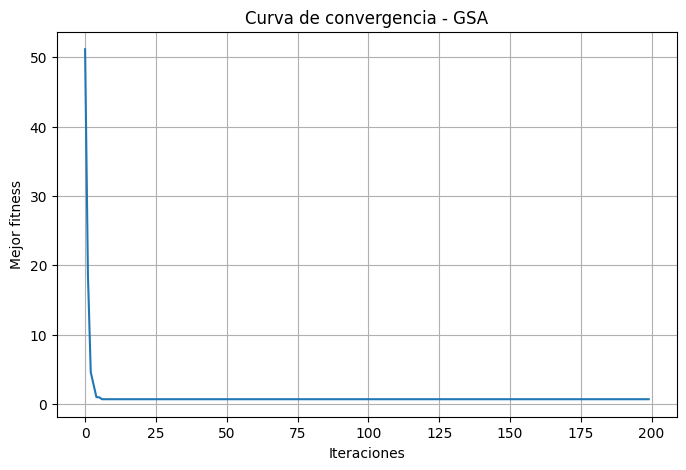

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(results["fitness_history"])
plt.title("Curva de convergencia - GSA")
plt.xlabel("Iteraciones")
plt.ylabel("Mejor fitness")
plt.grid(True)
plt.show()

**10.2** Experimento con diferentes semillas


=== 2. EXPERIMENTO: DIFERENTES SEMILLAS ===
Corrida 1 (seed=1): Mejor fitness = 0.522698
Corrida 2 (seed=7): Mejor fitness = 0.444023
Corrida 3 (seed=13): Mejor fitness = 0.106863
Corrida 4 (seed=21): Mejor fitness = 0.235405
Corrida 5 (seed=42): Mejor fitness = 0.674698
Corrida 6 (seed=55): Mejor fitness = 0.581530
Corrida 7 (seed=77): Mejor fitness = 0.610730
Corrida 8 (seed=99): Mejor fitness = 0.388337
Corrida 9 (seed=123): Mejor fitness = 0.305545
Corrida 10 (seed=202): Mejor fitness = 0.882941


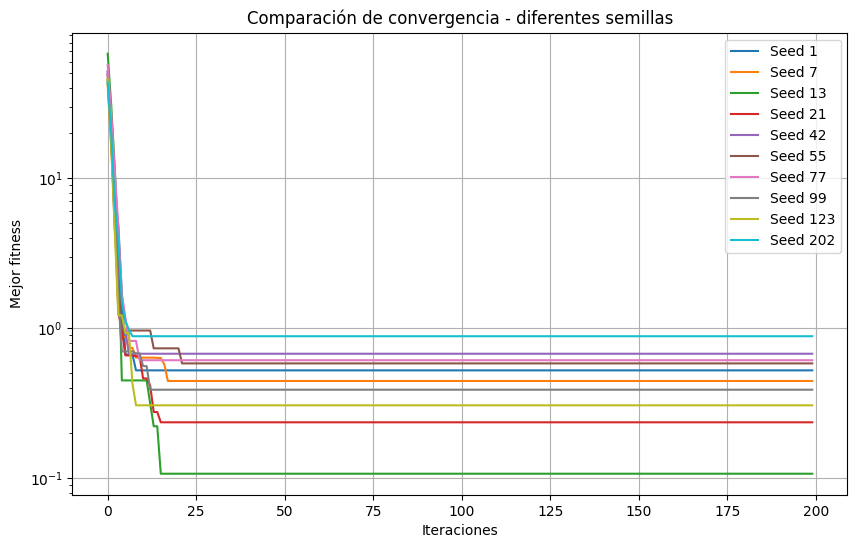

In [ ]:
print("\n=== 2. EXPERIMENTO: DIFERENTES SEMILLAS ===")

seeds = [1, 7, 13, 21, 42, 55, 77, 99, 123, 202]
best_fitness_list = []
histories = []

for i, seed in enumerate(seeds, start=1):
    config = GSAConfig(seed=seed)
    results = run_gsa(config)

    best_fitness_list.append(results["best_fitness"])
    histories.append((seed, results["fitness_history"]))

    print(f"Corrida {i} (seed={seed}): Mejor fitness = {results['best_fitness']:.6f}")

plt.figure(figsize=(10, 6))

for seed, history in histories:
    plt.plot(history, label=f"Seed {seed}")

plt.title("Comparación de convergencia - diferentes semillas")
plt.xlabel("Iteraciones")
plt.yscale('log')
plt.ylabel("Mejor fitness")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("\n=== RESUMEN ESTADÍSTICO ===")
print(f"Mejor fitness de todas las corridas: {np.min(best_fitness_list):.6f}")
print(f"Peor fitness de todas las corridas: {np.max(best_fitness_list):.6f}")
print(f"Promedio de fitness: {np.mean(best_fitness_list):.6f}")
print(f"Desviación estándar: {np.std(best_fitness_list):.6f}")


=== RESUMEN ESTADÍSTICO ===
Mejor fitness de todas las corridas: 0.106863
Peor fitness de todas las corridas: 0.882941
Promedio de fitness: 0.475277
Desviación estándar: 0.216438


In [ ]:
results_table = pd.DataFrame({
    "Seed": seeds,
    "Best Fitness": best_fitness_list
})

results_table = results_table.sort_values(by="Best Fitness")

print("\n=== TABLA DE RESULTADOS (ORDENADA) ===")
print(results_table)


=== TABLA DE RESULTADOS (ORDENADA) ===
   Seed  Best Fitness
2    13      0.106863
3    21      0.235405
8   123      0.305545
7    99      0.388337
1     7      0.444023
0     1      0.522698
5    55      0.581530
6    77      0.610730
4    42      0.674698
9   202      0.882941
